# exp_20260420_baseline_yolo26n

**목적**: YOLO26n Stage 1 (pill detection) 베이스라인 학습·검증 + Stage 2 분류기 연동 시각화  
**설정 파일**: `experiments/exp_20260420_baseline_yolo26n/config.yaml`  
**데이터셋**: `data/preprocessed/dataset.yaml` (nc=1, class: pill)

| 항목 | 값 |
|------|----|
| 모델 | yolo26n (pretrained) |
| imgsz | 640 |
| epochs | 100 |
| batch | 16 |
| optimizer | auto |

**노트북 흐름**
```
[scripts/train.py] → [scripts/validate.py] → [scripts/predict.py]
    → crop 추출(notebook) → Stage 2 분류(notebook) → 통합 시각화(notebook)
```

## 0. 환경 설정

In [71]:
import os
from pathlib import Path

# notebooks/ 한 단계 위 or 이미 프로젝트 루트면 그대로
_cwd = Path.cwd()
PROJECT_ROOT = _cwd if (_cwd / "experiments").exists() else _cwd.parent
os.chdir(PROJECT_ROOT)

print("cwd:", os.getcwd())

cwd: /home/n132/Projects/Project1/Main


In [72]:
# 시각화·분석용 import (스크립트 호출과 무관)
import json
import random
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

try:
    import koreanize_matplotlib
except ImportError:
    # Kaggle 환경에서 미설치 시 설치 후 임포트
    import subprocess
    subprocess.run(["pip", "install", "-q", "koreanize-matplotlib"])
    import koreanize_matplotlib


print("imports OK")

imports OK


## 1. Config 및 데이터 경로 확인

In [73]:
# 실험 전반에서 공유하는 경로 변수
EXP_NAME    = "exp_20260420_baseline_yolo26n"
S1_CONFIG   = f"experiments/{EXP_NAME}/s1_config.yaml"
S2_CONFIG   = f"experiments/{EXP_NAME}/s2_config.yaml"
DATA_YAML   = "data/processed/dataset.yaml"
BEST_PT_S1  = f"experiments/{EXP_NAME}/weights/best.pt"
PRED_OUTPUT = f"experiments/{EXP_NAME}/val_predictions.json"
CROP_DIR    = Path(f"experiments/{EXP_NAME}/stage1_crops")

BEST_PT_S2     = f"experiments/{EXP_NAME}/stage2/weights/best.pt"
S2_PRED_OUTPUT = f"experiments/{EXP_NAME}/stage2_predictions.json"

print(f"s1_config : {S1_CONFIG}  [{Path(S1_CONFIG).exists()}]")
print(f"s2_config : {S2_CONFIG}  [{Path(S2_CONFIG).exists()}]")
print(f"data      : {DATA_YAML}  [{Path(DATA_YAML).exists()}]")

s1_config : experiments/exp_20260420_baseline_yolo26n/s1_config.yaml  [True]
s2_config : experiments/exp_20260420_baseline_yolo26n/s2_config.yaml  [True]
data      : data/processed/dataset.yaml  [True]


In [74]:
with open(S1_CONFIG) as f:
    cfg = yaml.safe_load(f)
print(yaml.dump(cfg, allow_unicode=True, default_flow_style=False))

albumentations:
  bbox:
    clip: true
    format: yolo
    label_fields:
    - class_labels
    min_visibility: 0.1
  brightness_contrast:
    brightness_limit: 0.15
    contrast_limit: 0.15
    p: 0.5
  gauss_noise:
    p: 0.15
    std_range:
    - 0.01
    - 0.03
  gaussian_blur:
    blur_limit:
    - 3
    - 5
    p: 0.2
  horizontal_flip:
    p: 0.5
  jpeg_compression:
    p: 0.3
    quality_lower: 85
    quality_upper: 100
  random_rotate90:
    p: 0.2
  shift_scale_rotate:
    p: 0.6
    rotate_limit: 8
    scale_limit: 0.08
    shift_limit: 0.03
  vertical_flip:
    p: 0.2
augment:
  copy_paste: 0.0
  fliplr: 0.5
  flipud: 0.0
  hsv_h: 0.015
  hsv_s: 0.7
  hsv_v: 0.4
  mixup: 0.1
  mosaic: 1.0
classes:
- pill
data:
  description: baseline detection dataset
  imgsz: 640
  version: v1.0
  workers: 4
  yaml: data/processed/dataset.yaml
model:
  name: yolo26n
  pretrained: true
nc: 1
output:
  name: exp_20260420_baseline_yolo26n
  project: experiments
  save_period: 10
seed: 42
sta

In [75]:
with open(DATA_YAML) as f:
    data_cfg = yaml.safe_load(f)

# yaml 내 경로는 yaml 파일 기준 상대경로
DATA_YAML_DIR = Path(DATA_YAML).parent

print("dataset.yaml:")
for split in ["train", "val", "test"]:
    p = (DATA_YAML_DIR / data_cfg[split]).resolve()
    count = len(list(p.glob("*.jpg"))) + len(list(p.glob("*.png"))) if p.exists() else -1
    print(f"  {split:5s}: {p}  [{'OK' if p.exists() else 'MISSING'}] images={count}")

VAL_IMG_DIR = (DATA_YAML_DIR / data_cfg["val"]).resolve()

dataset.yaml:
  train: /home/n132/Projects/Project1/Main/data/processed/images/train  [OK] images=3981
  val  : /home/n132/Projects/Project1/Main/data/processed/images/val  [OK] images=497
  test : /home/n132/Projects/Project1/Main/data/processed/images/test  [OK] images=499


## 2. Stage 1 학습

```bash
python scripts/train.py --config <config> --data <data>
```

In [ ]:
!python scripts/train.py \
    --config {S1_CONFIG} \
    --data   {DATA_YAML}

/home/n132/anaconda3/envs/P1/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
New https://pypi.org/project/ultralytics/8.4.41 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=0.1, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/n132/Projects/Project1/Main/data/processed/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscr

## 3. 검증

```bash
python scripts/validate.py --config <config> --data <data>
```

In [ ]:
!python scripts/validate.py \
    --config  {S1_CONFIG} \
    --data    {DATA_YAML}

Transferred 606/708 items from pretrained weights
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
YOLO26n summary (fused): 122 layers, 2,408,932 parameters, 0 gradients, 5.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2255.3±552.1 MB/s, size: 51.4 KB)
val: Scanning /home/n132/Projects/Project1/Main/data/processed/labels/val.cache... 497 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 497/497 99.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 6.6it/s 4.9s0.1s
                   all        497        547      0.668      0.128      0.193      0.178
                person        497        547      0.668      0.128      0.193      0.178
Speed: 1.6ms preprocess, 3.6ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /home/n132/Projects/Project1/Main/runs/detect/val-3
mAP50=0.1934  mAP50-95=0.1781


## 4. 학습 곡선 시각화

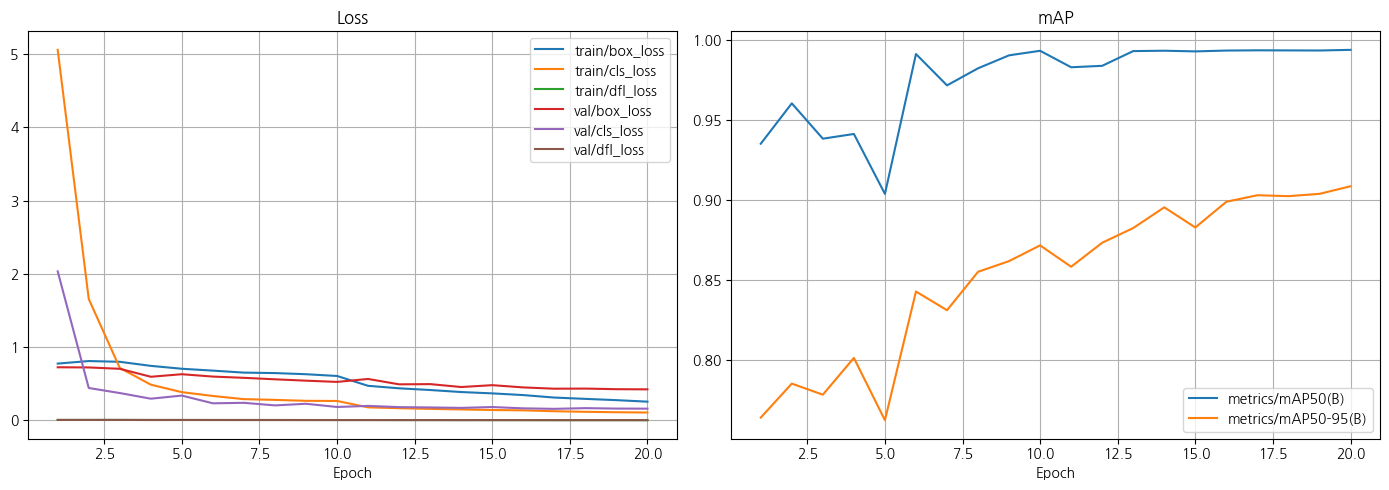

In [ ]:
import pandas as pd

RESULTS_CSV = Path(f"experiments/{EXP_NAME}/results.csv")

if not RESULTS_CSV.exists():
    print("results.csv 없음 — 학습 후 재실행하세요")
else:
    df = pd.read_csv(RESULTS_CSV)
    df.columns = df.columns.str.strip()

    loss_cols = [c for c in df.columns if "loss" in c.lower()]
    map_cols  = [c for c in df.columns if "map"  in c.lower()]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for col in loss_cols:
        axes[0].plot(df["epoch"], df[col], label=col)
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
    axes[0].legend(); axes[0].grid(True)

    for col in map_cols:
        axes[1].plot(df["epoch"], df[col], label=col)
    axes[1].set_title("mAP"); axes[1].set_xlabel("Epoch")
    axes[1].legend(); axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"experiments/{EXP_NAME}/training_curves.png", dpi=150)
    plt.show()

## 5. Stage 1 추론 (val set)

```bash
python scripts/predict.py --config <config> --source <val_dir> --output <output_json>
```

In [ ]:
!python scripts/predict.py \
    --config  {S1_CONFIG} \
    --source  {VAL_IMG_DIR} \
    --output  {PRED_OUTPUT}

Transferred 606/708 items from pretrained weights

image 1/497 /home/n132/Projects/Project1/Main/data/processed/images/val/ext_125mg-Madopar-HBS-cap-_jpg.rf.1816183d8912e67d3a8e14f9204e5e02.jpg: 640x640 (no detections), 23.2ms
image 2/497 /home/n132/Projects/Project1/Main/data/processed/images/val/ext_125mg-Madopar-HBS-cap_12_jpg.rf.6056b05c6f5934678b2415423b11dc14.jpg: 640x640 (no detections), 13.2ms
image 3/497 /home/n132/Projects/Project1/Main/data/processed/images/val/ext_20230316_074544051_iOS_jpg.rf.45b1ee23f3d21d0fb618c81544727e2f.jpg: 640x640 (no detections), 12.9ms
image 4/497 /home/n132/Projects/Project1/Main/data/processed/images/val/ext_20230316_075432749_iOS_jpg.rf.7935e9ef2b6e81da4ee5e506d8e17302.jpg: 640x640 (no detections), 12.7ms
image 5/497 /home/n132/Projects/Project1/Main/data/processed/images/val/ext_20230316_080700940_iOS_jpg.rf.f4c87c380180c441af59107b651fe8fa.jpg: 640x640 (no detections), 13.1ms
image 6/497 /home/n132/Projects/Project1/Main/data/processed/images

In [ ]:
with open(PRED_OUTPUT) as f:
    predictions = json.load(f)

total_det = sum(len(p["detections"]) for p in predictions)
print(f"이미지 수 : {len(predictions)}")
print(f"총 탐지 수: {total_det}  (평균 {total_det/max(len(predictions),1):.1f}개/장)")

이미지 수 : 497
총 탐지 수: 7  (평균 0.0개/장)


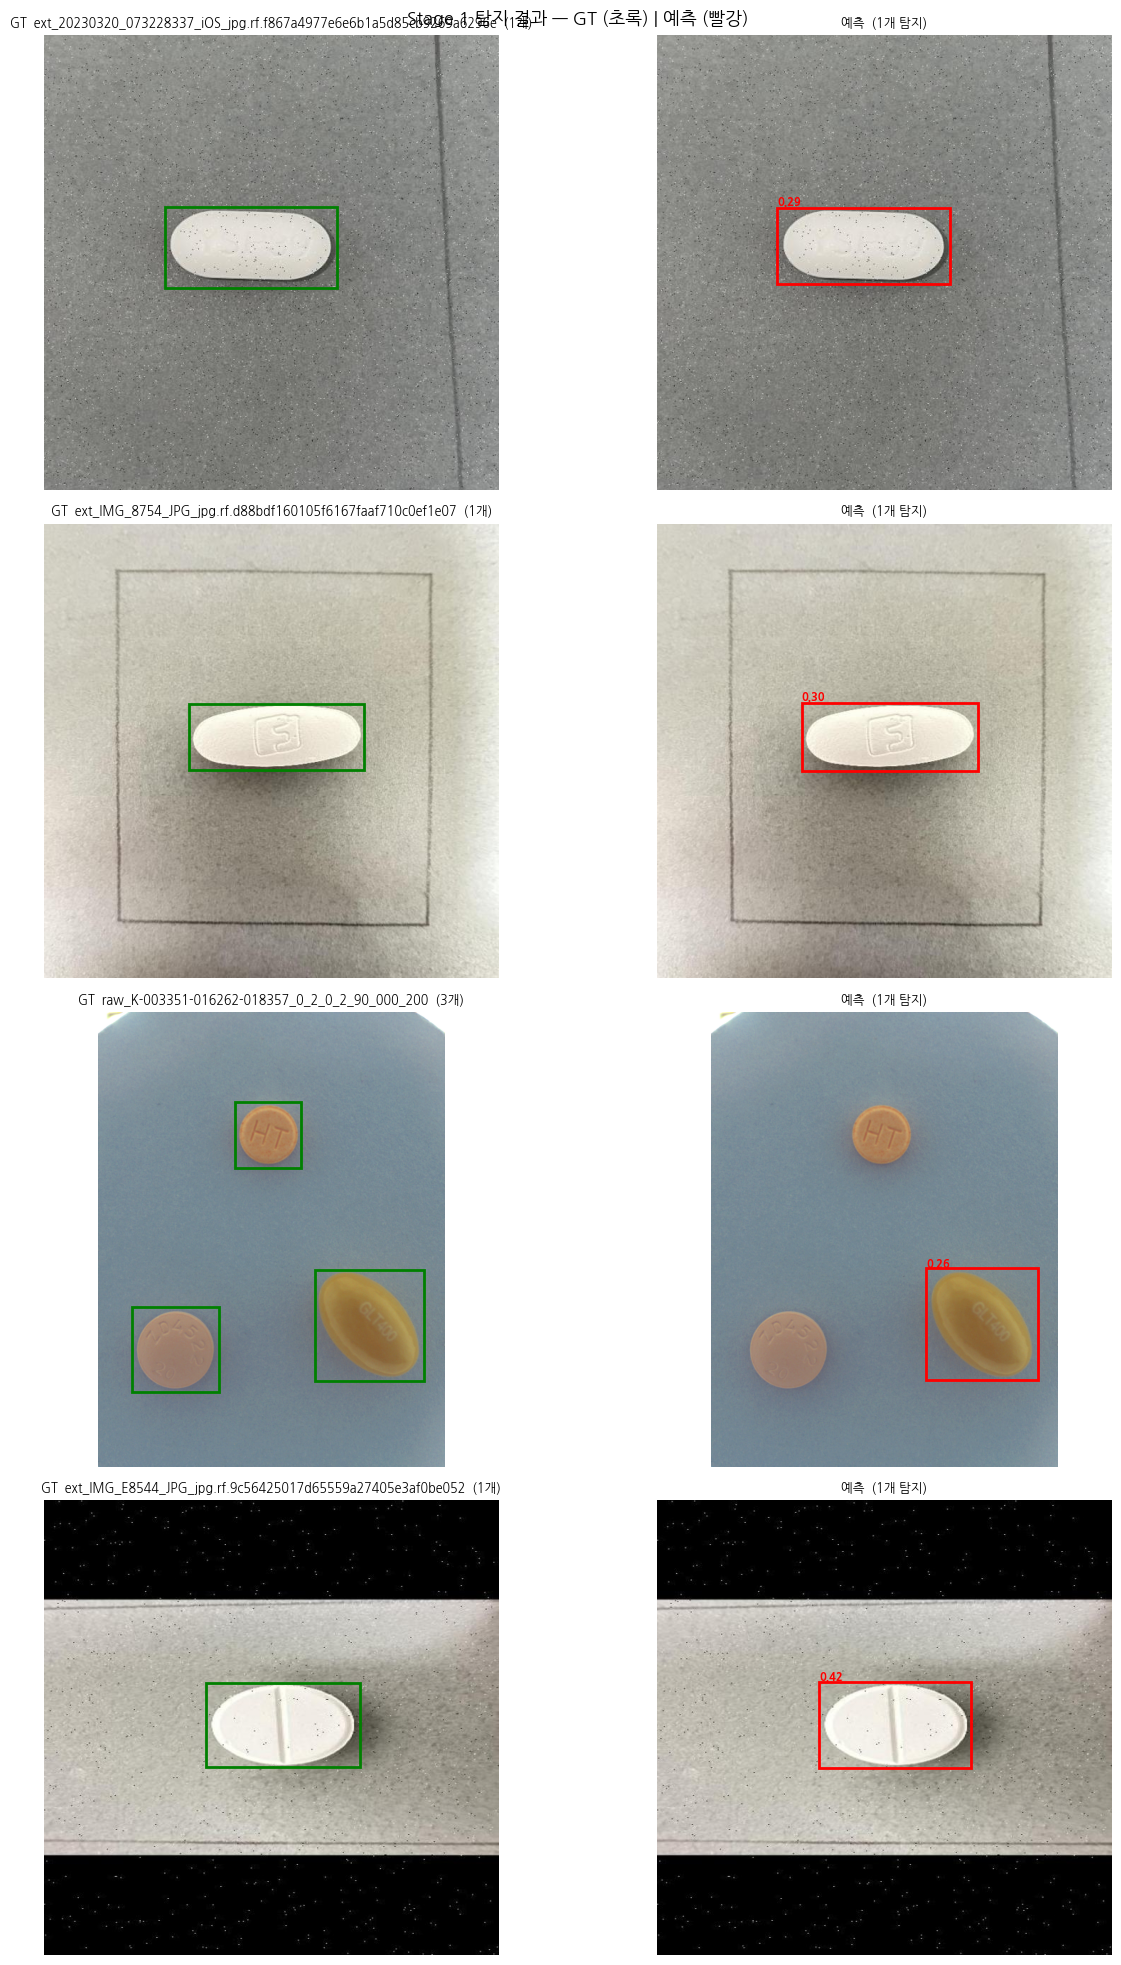

In [ ]:
VAL_LABEL_DIR = Path("data/processed/labels/val")

has_det    = [p for p in predictions if p["detections"]]
samples_s1 = random.sample(has_det, min(4, len(has_det)))

fig, axes = plt.subplots(len(samples_s1), 2, figsize=(14, 5 * len(samples_s1)))
if len(samples_s1) == 1:
    axes = axes[np.newaxis, :]

for row, sample in enumerate(samples_s1):
    candidates = list(VAL_IMG_DIR.glob(f"{sample['image_id']}.*"))
    if not candidates:
        axes[row, 0].axis("off"); axes[row, 1].axis("off"); continue

    img = np.array(Image.open(candidates[0]).convert("RGB"))
    H, W = img.shape[:2]

    # GT 라벨 로드 (YOLO format: class cx cy w h normalized)
    label_path = VAL_LABEL_DIR / f"{sample['image_id']}.txt"
    gt_boxes = []
    if label_path.exists():
        for line in label_path.read_text().strip().splitlines():
            _, cx, cy, bw, bh = map(float, line.split())
            x1 = (cx - bw / 2) * W
            y1 = (cy - bh / 2) * H
            x2 = (cx + bw / 2) * W
            y2 = (cy + bh / 2) * H
            gt_boxes.append((x1, y1, x2, y2))

    # 왼쪽: 원본 + GT 라벨
    axes[row, 0].imshow(img)
    for x1, y1, x2, y2 in gt_boxes:
        axes[row, 0].add_patch(patches.Rectangle(
            (x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor="green", facecolor="none"
        ))
    axes[row, 0].set_title(f"GT  {sample['image_id']}  ({len(gt_boxes)}개)", fontsize=9)
    axes[row, 0].axis("off")

    # 오른쪽: 예측 bbox
    axes[row, 1].imshow(img)
    for det in sample["detections"]:
        x1, y1, x2, y2 = det["bbox"]
        axes[row, 1].add_patch(patches.Rectangle(
            (x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor="red", facecolor="none"
        ))
        axes[row, 1].text(
            x1, y1 - 4, f"{det['score']:.2f}",
            color="red", fontsize=8, fontweight="bold"
        )
    axes[row, 1].set_title(f"예측  ({len(sample['detections'])}개 탐지)", fontsize=9)
    axes[row, 1].axis("off")

plt.suptitle("Stage 1 탐지 결과 — GT (초록) | 예측 (빨강)", fontsize=13)
plt.tight_layout()
plt.show()

## 6. 중간 crop 추출 및 시각화

Stage 1 bbox를 원본 이미지에서 잘라내어 Stage 2 입력 디렉터리를 만든다.  
파일명: `{image_id}_{idx:04d}.jpg` / 매니페스트: `crops_manifest.json`

In [ ]:
!python scripts/pipeline/crop.py \
    --predictions {PRED_OUTPUT} \
    --source      {VAL_IMG_DIR} \
    --output      {CROP_DIR} \
    --padding     0.05


crop 추출 완료: 7개 → experiments/exp_20260420_baseline_yolo26n/stage1_crops


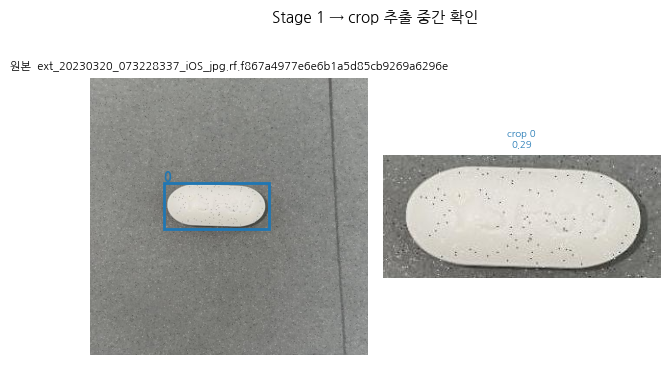

In [ ]:
with open(CROP_DIR / 'crops_manifest.json') as f:
    manifest = json.load(f)

# 탐지 수 가장 많은 이미지 1장: 원본 + 각 crop 나란히
manifest_by_img = {}
for item in manifest:
    manifest_by_img.setdefault(item["image_id"], []).append(item)

showcase_id    = max(manifest_by_img, key=lambda k: len(manifest_by_img[k]))
showcase_crops = manifest_by_img[showcase_id]
n              = len(showcase_crops)

orig_img = np.array(Image.open(next(VAL_IMG_DIR.glob(f"{showcase_id}.*"))).convert("RGB"))

fig, axes = plt.subplots(1, n + 1, figsize=(3 * (n + 1), 4))
axes[0].imshow(orig_img)
for i, item in enumerate(showcase_crops):
    color = plt.cm.tab10.colors[i % 10]
    x1, y1, x2, y2 = item["bbox"]
    axes[0].add_patch(patches.Rectangle(
        (x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor=color, facecolor="none"
    ))
    axes[0].text(x1, y1-5, str(i), color=color, fontsize=9, fontweight="bold")
axes[0].set_title(f"원본  {showcase_id}", fontsize=8)
axes[0].axis("off")

for i, item in enumerate(showcase_crops):
    color = plt.cm.tab10.colors[i % 10]
    axes[i+1].imshow(Image.open(CROP_DIR / f"{item['crop_id']}.jpg").convert("RGB"))
    axes[i+1].set_title(f"crop {i}\n{item['score']:.2f}", fontsize=7, color=color)
    axes[i+1].axis("off")

plt.suptitle("Stage 1 → crop 추출 중간 확인", fontsize=11)
plt.tight_layout()
plt.savefig(f"experiments/{EXP_NAME}/crop_samples.png", dpi=150)
plt.show()

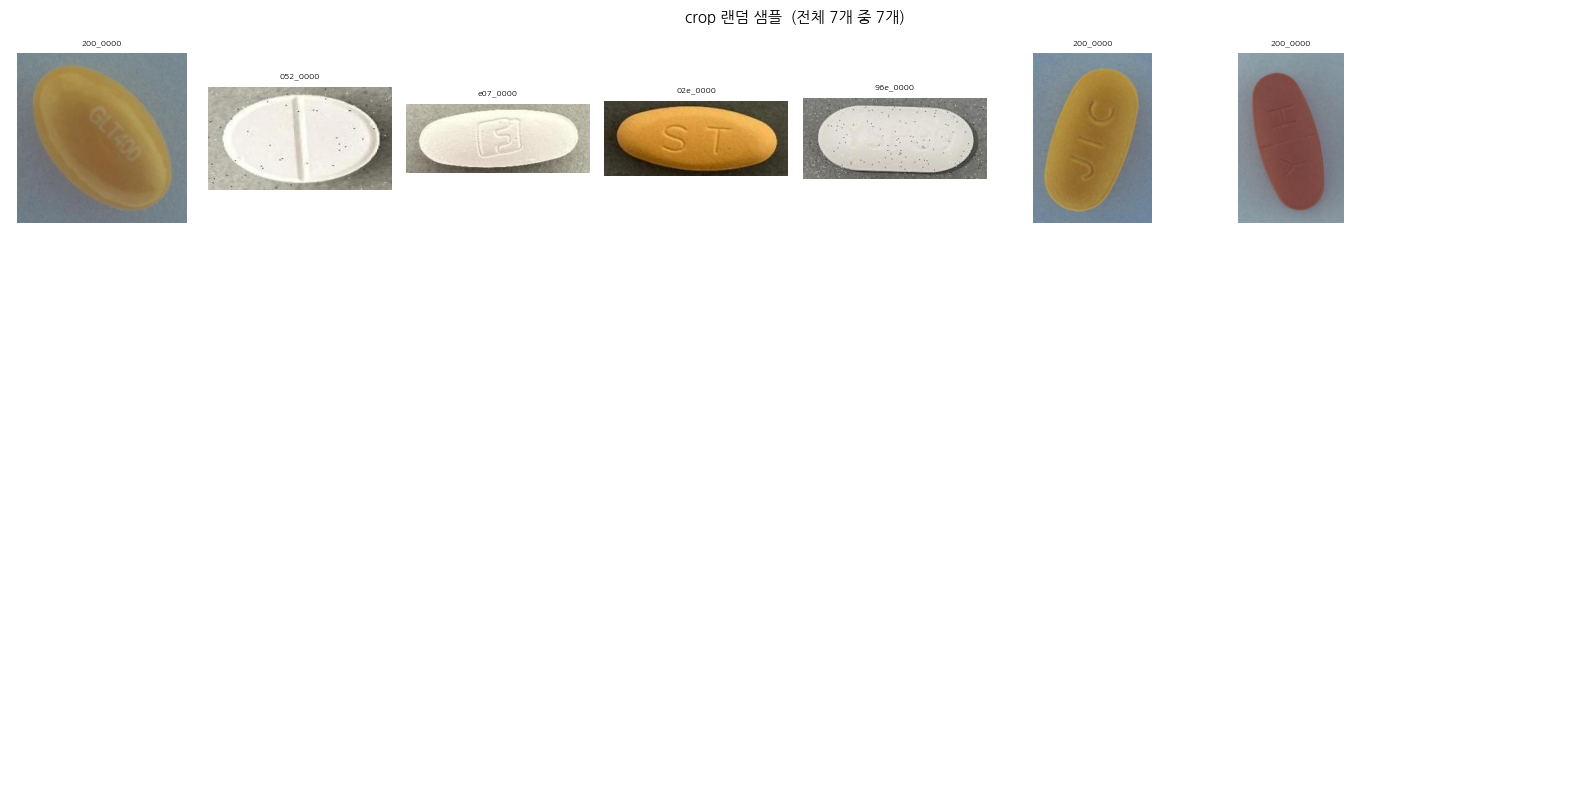

In [ ]:
# 랜덤 32개 crop 그리드 — 전반적인 crop 품질 확인
crop_files   = sorted(CROP_DIR.glob("*.jpg"))
sample_files = random.sample(crop_files, min(32, len(crop_files)))

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for ax, f in zip(axes.flatten(), sample_files):
    ax.imshow(Image.open(f).convert("RGB"))
    ax.set_title(f.stem[-8:], fontsize=6)
    ax.axis("off")
for ax in axes.flatten()[len(sample_files):]:
    ax.axis("off")

plt.suptitle(f"crop 랜덤 샘플  (전체 {len(crop_files)}개 중 {len(sample_files)}개)", fontsize=11)
plt.tight_layout()
plt.show()

## 7. Stage 2 분류 실행

```bash
python scripts/predict.py  # Stage 2 스크립트가 별도 준비된 경우
```

> Stage 2 전용 스크립트가 없는 경우 아래 셀이 `Classifier` API를 직접 호출한다.  
> `BEST_PT_S2`가 없으면 경고 출력 후 건너뜀.

In [ ]:
print("Stage 2 config :", S2_CONFIG,  "[", Path(S2_CONFIG).exists(),  "]")
print("Stage 2 best.pt:", BEST_PT_S2, "[", Path(BEST_PT_S2).exists(), "]")

Stage 2 config : experiments/exp_20260420_baseline_yolo26n/s2_config.yaml [ True ]
Stage 2 best.pt: experiments/exp_20260420_baseline_yolo26n/stage2/weights/best.pt [ False ]


### 7-1. Stage 2 학습

```bash
python scripts/pipeline/stage2_train.py --config <s2_config> --data <crops_root>
```

In [ ]:
!python scripts/pipeline/stage2_train.py \
    --config {S2_CONFIG}

/home/n132/anaconda3/envs/P1/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
Traceback (most recent call last):
  File "/home/n132/Projects/Project1/Main/scripts/pipeline/stage2_train.py", line 53, in <module>
    main()
  File "/home/n132/Projects/Project1/Main/scripts/pipeline/stage2_train.py", line 40, in main
    train_ds = Stage2Dataset(train_dir, cfg, split="train")
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/n132/Projects/Project1/Main/src/data/stage2_dataset.py", line 34, in __init__
    self.classes = sorted(d.name for d in self.root.iterdir() if d.is_dir())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/n132/Projects/Project1/Main/src/data/stage2_dataset.py", line 34, in <genexpr>
    self.classes = sorted(d.name for d in self.root.iterdi

### 7-2. Stage 2 추론

```bash
python scripts/pipeline/stage2_predict.py --config <s2_config> --source <crop_dir>
```

In [ ]:
if not Path(BEST_PT_S2).exists():
    print("\n⚠️  가중치 없음 — 7-1 학습 셀을 먼저 실행하세요")

!python scripts/pipeline/stage2_predict.py \
    --config  {S2_CONFIG} \
    --weights {BEST_PT_S2} \
    --source  {CROP_DIR} \
    --output  {S2_PRED_OUTPUT}


⚠️  가중치 없음 — 7-1 학습 셀을 먼저 실행하세요
model.safetensors: 100%|█████████████████████| 102M/102M [00:10<00:00, 9.47MB/s]
Traceback (most recent call last):
  File "/home/n132/Projects/Project1/Main/scripts/pipeline/stage2_predict.py", line 44, in <module>
    main()
  File "/home/n132/Projects/Project1/Main/scripts/pipeline/stage2_predict.py", line 28, in main
    classifier = Classifier(cfg).load_weights(weights)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/n132/Projects/Project1/Main/src/models/classifier.py", line 43, in load_weights
    checkpoint = torch.load(path, map_location="cpu")
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/n132/anaconda3/envs/P1/lib/python3.12/site-packages/torch/serialization.py", line 1530, in load
    with _open_file_like(f, "rb") as opened_file:
         ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/n132/anaconda3/envs/P1/lib/python3.12/site-packages/torch/serialization.py", line 795, in _open_file_like
    return _open_f

## 8. 2-Stage 파이프라인 통합 시각화

In [ ]:
if not Path(S2_PRED_OUTPUT).exists():
    print("Stage 2 결과 없음 — 7번 섹션을 먼저 실행하세요")
else:
    with open(S2_PRED_OUTPUT) as f:
        s2_results = json.load(f)

    s2_by_crop = {r["crop_id"]: r for r in s2_results}

    pipeline_by_img = {}
    for item in manifest:
        s2 = s2_by_crop.get(item["crop_id"], {})
        pipeline_by_img.setdefault(item["image_id"], []).append({
            "bbox":        item["bbox"],
            "det_score":   item["score"],
            "crop_id":     item["crop_id"],
            "class_name":  s2.get("class_name", "?"),
            "class_score": s2.get("score", 0.0),
        })

    print(f"파이프라인 결과: {len(pipeline_by_img)}장")

Stage 2 결과 없음 — 7번 섹션을 먼저 실행하세요


In [ ]:
# 이미지별 오버레이 4장 — bbox + Stage 2 클래스명
if not Path(S2_PRED_OUTPUT).exists():
    print("Stage 2 결과 없음")
else:
    sample_ids = random.sample(list(pipeline_by_img.keys()), min(4, len(pipeline_by_img)))

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    for ax, img_id in zip(axes.flatten(), sample_ids):
        candidates = list(VAL_IMG_DIR.glob(f"{img_id}.*"))
        if not candidates:
            ax.axis("off"); continue

        img = np.array(Image.open(candidates[0]).convert("RGB"))
        ax.imshow(img)
        for i, item in enumerate(pipeline_by_img[img_id]):
            x1, y1, x2, y2 = item["bbox"]
            color = plt.cm.tab10.colors[i % 10]
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor=color, facecolor="none"
            ))
            ax.text(
                x1, y2 + 4,
                f"{item['class_name']}\n{item['class_score']:.2f}",
                color="white", fontsize=7, fontweight="bold",
                bbox=dict(facecolor=color, alpha=0.7, pad=1, edgecolor="none")
            )
        ax.set_title(f"{img_id}  ({len(pipeline_by_img[img_id])}개)", fontsize=9)
        ax.axis("off")

    plt.suptitle("2-Stage 통합 결과: Stage1 bbox + Stage2 클래스명", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"experiments/{EXP_NAME}/pipeline_overlay.png", dpi=150)
    plt.show()

Stage 2 결과 없음


In [ ]:
# 스트립 뷰 — 탐지 수 가장 많은 이미지 1장
# 상단: 원본+bbox  /  하단 각 열: crop → 분류 결과
if not Path(S2_PRED_OUTPUT).exists():
    print("Stage 2 결과 없음")
else:
    strip_id    = max(pipeline_by_img, key=lambda k: len(pipeline_by_img[k]))
    strip_items = pipeline_by_img[strip_id]
    n           = len(strip_items)

    fig, axes = plt.subplots(3, n + 1, figsize=(3 * (n + 1), 9))

    # 좌측 첫 열: 원본 + bbox (3행을 합쳐서 표시)
    from matplotlib.gridspec import GridSpec
    fig.clf()
    gs  = GridSpec(3, n + 1, figure=fig)
    ax0 = fig.add_subplot(gs[:, 0])          # 세 행 전체
    orig_img = np.array(Image.open(next(VAL_IMG_DIR.glob(f"{strip_id}.*"))).convert("RGB"))
    ax0.imshow(orig_img)
    for i, item in enumerate(strip_items):
        color = plt.cm.tab10.colors[i % 10]
        x1, y1, x2, y2 = item["bbox"]
        ax0.add_patch(patches.Rectangle(
            (x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor=color, facecolor="none"
        ))
        ax0.text(x1, y1-5, str(i), color=color, fontsize=9, fontweight="bold")
    ax0.set_title(f"원본  {strip_id}", fontsize=8)
    ax0.axis("off")

    # 나머지 열: 행0=번호, 행1=crop, 행2=분류결과
    for i, item in enumerate(strip_items):
        color = plt.cm.tab10.colors[i % 10]

        ax_num  = fig.add_subplot(gs[0, i + 1])
        ax_crop = fig.add_subplot(gs[1, i + 1])
        ax_cls  = fig.add_subplot(gs[2, i + 1])

        ax_num.text(0.5, 0.5, str(i), ha="center", va="center",
                    fontsize=16, fontweight="bold", color=color,
                    transform=ax_num.transAxes)
        ax_num.axis("off")

        ax_crop.imshow(Image.open(CROP_DIR / f"{item['crop_id']}.jpg").convert("RGB"))
        ax_crop.set_title(f"det={item['det_score']:.2f}", fontsize=7)
        ax_crop.axis("off")

        ax_cls.text(
            0.5, 0.5,
            f"{item['class_name']}\n{item['class_score']:.3f}",
            ha="center", va="center", fontsize=7, fontweight="bold",
            transform=ax_cls.transAxes,
            bbox=dict(facecolor=color, alpha=0.25, pad=3)
        )
        ax_cls.axis("off")

    plt.suptitle(f"2-Stage 스트립 — {strip_id}", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"experiments/{EXP_NAME}/pipeline_strip.png", dpi=150)
    plt.show()

Stage 2 결과 없음


## 9. 결과 요약

In [ ]:
print("=" * 45)
print(f"  {EXP_NAME}")
print("=" * 45)
print(f"  model     : {cfg['model']['name']}")
print(f"  imgsz     : {cfg['data']['imgsz']}")
print(f"  epochs    : {cfg['train']['epochs']}")
print(f"  batch     : {cfg['train']['batch']}")
print("-" * 45)
print(f"  총 탐지   : {total_det}개  ({total_det/max(len(predictions),1):.1f}/장)")
print(f"  crop 수   : {crop_count}")
print("=" * 45)
print(f"  S1 preds  : {PRED_OUTPUT}")
print(f"  crops     : {CROP_DIR}")
if Path(S2_PRED_OUTPUT).exists():
    print(f"  S2 preds  : {S2_PRED_OUTPUT}")

  exp_20260420_baseline_yolo26n
  model     : yolo26n
  imgsz     : 640
  epochs    : 20
  batch     : 16
---------------------------------------------
  총 탐지   : 7개  (0.0/장)
  crop 수   : 7
  S1 preds  : experiments/exp_20260420_baseline_yolo26n/val_predictions.json
  crops     : experiments/exp_20260420_baseline_yolo26n/stage1_crops
